# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [1]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Implement the "kernel" method to visualize a pdf approximated by weighted impulses

In [2]:
% Select the kernel function to use when approximating the pdf

KernelFunction = (@(x)(35/32)*(1-x.^2).^3.*(abs(x)<=1)); % Tri-weight
% KernelFunction = (@(x)(15/16)*(1-x.^2).^2.*(abs(x)<=1)); % Bi-weight
%KernelFunction = (@(x) (1/sqrt(pi))*exp(-x.^2)); % Gaussian
width = 0.6;     % The width parameter for the kernel function

In [3]:
nSamples     = 2000;  % Number of weighted impulses to use in pdf approximation
sigma        = 1;    % Standard deviation of Gaussian being approximated
xAxisMin = -4*sigma; % For computing and plotting... the range of "x"
xAxisMax =  4*sigma;

randn("state",0); rand("state",0); randg("state",0); % To get consistent results from run to run
xSample = trnd(2,nSamples,1);              % Draw random samples from the Student-t importance density
q       = tpdf(xSample,2);                 % Evaluate Student-t pdf at each of these sample locations
p       = normpdf(xSample,0,sigma);        % Evaluate the Gaussian we seek to approximate, evaluated at same locs.
w       = p./q;                            % Compute impulse weights

x       = linspace(xAxisMin,xAxisMax,500); % An evenly spaced "x" vector for creating estimate of Gaussian
ny      = normpdf(x,0,sigma);              % The true value we are seeking to estimate (of "N"ormal distn.)
ty      = tpdf(x,2);                       % The Student-t value at the same locations (of "T" distn.)

In [4]:
pdfEst = zeros(size(x));                   % Initialize the kernel estimate to zero
for k = 1:nSamples                         % Add in the "bump" kernel function for each sample
  pdfEst = pdfEst + w(k) * (1/width*KernelFunction((x-xSample(k))/width));
end
pdfEst = pdfEst/nSamples;                  % Normalize to have (nominal) area of 1

### Plot results

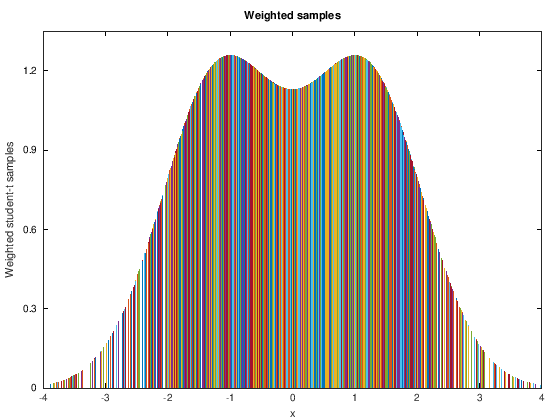

In [5]:
plot([xSample'; xSample'],[zeros(1,nSamples);w'],'-'); % Plot the weighted samples
  xlim([xAxisMin xAxisMax]); 
  ylim([0 1.35]); set(gca,'ytick',0:0.3:1.5)
  xlabel('x'); ylabel('Weighted student-t samples');
  title('Weighted samples')

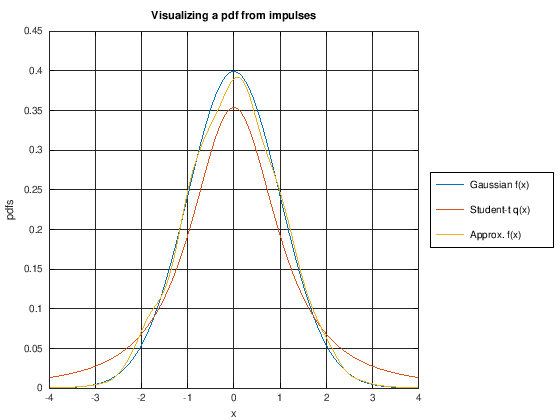

In [6]:
plot(x,ny,x,ty,x,pdfEst); % Plot the pdfs
xlabel('x'); ylabel('pdfs'); 
title('Visualizing a pdf from impulses');
xlim([xAxisMin xAxisMax]); ylim([0 0.45]); grid on
legend('Gaussian f(x)','Student-t q(x)','Approx. f(x)','location','eastoutside')

### Introducing the Hellinger distance as a metric of how well two pdfs match each other
The Hellinger distance between two pdfs $f_1(x)$ and $f_2(x)$ is defined as $$1-\int_{-\infty}^{\infty} \sqrt{f_1(x) f_2(x)} dx.$$
When the distance is zero, the pdfs are identical. When the distance is 1, the pdfs are as far apart as they can be. We are hoping that our approximate pdf has a Hellinger distance close to zero.

In [7]:
% We need to approximate the integral in the Hellinger distance with a sum. We'll use rectangular
% integration over the previously defined variable x
dx = mean(diff(x)); % the width of the summation bins
H = 1 - dx*sum(sqrt(ny.*pdfEst)); % f1 = y; f2 = pdfEst

fprintf('The Hellinger distance for this set of parameters is %g\n',H);

The Hellinger distance for this set of parameters is 0.00242389
